In [1]:
pip install sentence-transformers faiss-cpu rank-bm25 transformers torch tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 39.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import glob
import json
from typing import List
from tqdm import tqdm

# CONFIG
DOC_SOURCES = {
    "transformers": "/Users/zapashniysergey/Downloads/vs code docs /VKR_HSE/transformers/docs/source/en",
    "datasets": "/Users/zapashniysergey/Downloads/vs code docs /VKR_HSE/datasets/docs/source",
    "diffusers": "/Users/zapashniysergey/Downloads/vs code docs /VKR_HSE/diffusers/docs/source/en",
}

OUTPUT_DIR = "rag_corpus"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "corpus.jsonl")

CHUNK_SIZE = 400
CHUNK_OVERLAP = 50

os.makedirs(OUTPUT_DIR, exist_ok=True)

# TEXT CLEANING (SAFE)
def clean_markdown(text: str) -> str:
    text = re.sub(r"```.*?```", "", text, flags=re.S)
    text = re.sub(r"`[^`]*`", "", text)
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    text = re.sub(r"#+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def chunk_text(text: str, size: int, overlap: int) -> List[str]:
    words = text.split()
    chunks = []
    start = 0

    while start < len(words):
        end = start + size
        chunk_words = words[start:end]

        if len(chunk_words) >= 50:
            chunks.append(" ".join(chunk_words))

        start += size - overlap

    return chunks


# BUILD CORPUS
total_chunks = 0

with open(OUTPUT_FILE, "w", encoding="utf-8") as out:
    for library, base_path in DOC_SOURCES.items():
        print(f"\nProcessing {library} documentation...")

        md_files = glob.glob(
            os.path.join(base_path, "**", "*.md"),
            recursive=True
        )

        print(f"Found {len(md_files)} markdown files")

        for file_path in tqdm(md_files):
            try:
                with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                    raw_text = f.read()
            except Exception:
                continue

            cleaned_text = clean_markdown(raw_text)
            chunks = chunk_text(cleaned_text, CHUNK_SIZE, CHUNK_OVERLAP)

            for chunk in chunks:
                record = {
                    "text": chunk,
                    "source": os.path.relpath(file_path, base_path),
                    "library": library
                }
                out.write(json.dumps(record, ensure_ascii=False) + "\n")
                total_chunks += 1

print("\nCorpus built successfully!")
print(f"Total chunks: {total_chunks}")

with open(os.path.join(OUTPUT_DIR, "stats.txt"), "w", encoding="utf-8") as f:
    f.write(f"Total chunks: {total_chunks}\n")


Processing transformers documentation...
Found 598 markdown files


  0%|          | 0/598 [00:00<?, ?it/s]

100%|██████████| 598/598 [00:00<00:00, 2522.60it/s]



Processing datasets documentation...
Found 4 markdown files


100%|██████████| 4/4 [00:00<00:00, 2340.24it/s]



Processing diffusers documentation...
Found 359 markdown files


100%|██████████| 359/359 [00:00<00:00, 3565.43it/s]


Corpus built successfully!
Total chunks: 1884


In [ ]:
import json
import numpy as np
from tqdm import tqdm

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss


# LOAD CORPUS

CORPUS_PATH = "rag_corpus/corpus.jsonl"

documents = []
metadata = []

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        documents.append(record["text"])
        metadata.append({
            "source": record["source"],
            "library": record["library"]
        })

print(f"Loaded {len(documents)} documents")


# BM25 RETRIEVAL

tokenized_docs = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_docs)


def bm25_retrieve(query: str, k: int = 5):
    scores = bm25.get_scores(query.lower().split())
    top_idx = np.argsort(scores)[::-1][:k]
    return [
        {
            "text": documents[i],
            "score": scores[i],
            **metadata[i]
        }
        for i in top_idx
    ]


# DENSE RETRIEVAL (SBERT + FAISS)

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

embedder = SentenceTransformer(EMBEDDING_MODEL)

print("Encoding documents...")
doc_embeddings = embedder.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

dim = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(doc_embeddings)

print("FAISS index built")


def dense_retrieve(query: str, k: int = 5):
    query_emb = embedder.encode(
        [query],
        normalize_embeddings=True
    )
    scores, idx = index.search(query_emb, k)

    return [
        {
            "text": documents[i],
            "score": float(scores[0][j]),
            **metadata[i]
        }
        for j, i in enumerate(idx[0])
    ]

# TEST INTERFACE

print("\nRetrieval system ready. Type 'exit' to stop.\n")

while True:
    query = input("Query: ")
    if query.lower() == "exit":
        break

    print("\n--- BM25 RESULTS ---")
    bm25_results = bm25_retrieve(query, k=3)
    for r in bm25_results:
        print(f"[{r['library']}] {r['text'][:200]}...\n")

    print("\n--- DENSE RESULTS ---")
    dense_results = dense_retrieve(query, k=3)
    for r in dense_results:
        print(f"[{r['library']}] {r['text'][:200]}...\n")

    print("=" * 80)

/Users/zapashniysergey/Downloads/vs code docs /my_env/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loaded 1884 documents
Encoding documents...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

FAISS index built

Retrieval system ready. Type 'exit' to stop.



In [ ]:
import random
import re
import numpy as np
from tqdm import tqdm



# QUERY GENERATION
def generate_query_from_chunk(text: str) -> str:
    """
    Take first 1–2 sentences from a chunk as a pseudo-query.
    """
    sentences = re.split(r"[.!?]", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    return " ".join(sentences[:2])

# EVALUATION
def evaluate_retriever(
    retrieve_fn,
    documents,
    metadata,
    k=5,
    n_samples=200,
    seed=42
):
    random.seed(seed)
    indices = random.sample(range(len(documents)), n_samples)

    hits = 0
    rr_sum = 0.0

    for idx in tqdm(indices, desc="Evaluating"):
        query = generate_query_from_chunk(documents[idx])
        true_source = metadata[idx]["source"]

        results = retrieve_fn(query, k=k)

        found = False
        for rank, res in enumerate(results, start=1):
            if res["source"] == true_source:
                hits += 1
                rr_sum += 1.0 / rank
                found = True
                break

    recall = hits / n_samples
    mrr = rr_sum / n_samples

    return {
        f"Recall@{k}": round(recall, 4),
        "MRR": round(mrr, 4),
        "Samples": n_samples
    }



# RUN EVALUATION
print("\nRunning BM25 evaluation...")
bm25_metrics = evaluate_retriever(
    bm25_retrieve,
    documents,
    metadata,
    k=5,
    n_samples=200
)

print("\nRunning Dense evaluation...")
dense_metrics = evaluate_retriever(
    dense_retrieve,
    documents,
    metadata,
    k=5,
    n_samples=200
)

print("\n=== RESULTS ===")
print("BM25 :", bm25_metrics)
print("Dense:", dense_metrics)


Running BM25 evaluation...


Evaluating: 100%|██████████| 200/200 [00:00<00:00, 206.68it/s]



Running Dense evaluation...


Evaluating: 100%|██████████| 200/200 [00:04<00:00, 44.78it/s]


=== RESULTS ===
BM25 : {'Recall@5': 0.515, 'MRR': 0.4921, 'Samples': 200}
Dense: {'Recall@5': 0.465, 'MRR': 0.4341, 'Samples': 200}


```
В наших экспериментах BM25 превосходит плотный поиск в протоколе оценки, учитывающем источник. Это ожидаемо, поскольку запросы формируются непосредственно из текста документа и имеют высокое лексическое совпадение с исходными документами. Плотный поиск менее эффективен в этих условиях, но остается выгодным для более абстрактных запросов пользователей.
```

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# LOAD LLM (simple baseline)

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

def generate_answer(context: str, question: str) -> str:
    prompt = f"""
You are an assistant answering questions based ONLY on the provided documentation context.
If the answer is not contained in the context, say "I don't know".

Context:
{context}

Question:
{question}

Answer:
"""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.2
        )

    return tokenizer.decode(output[0], skip_special_tokens=True).split("Answer:")[-1].strip()


# REAL USER QUERIES

TEST_QUERIES = [
    "What is the Trainer class used for in transformers?",
    "How can I fine-tune a pretrained transformer model?",
    "How do I load a dataset from the Hugging Face Hub?",
    "What is the difference between AutoModel and AutoModelForSequenceClassification?",
    "How are diffusion pipelines used in diffusers?"
]

TOP_K = 5

# RUN RAG DEMO

for query in TEST_QUERIES:
    print("=" * 100)
    print(f"QUERY:\n{query}\n")

    retrieved = dense_retrieve(query, k=TOP_K)

    print("RETRIEVED CONTEXT (top chunks):\n")
    for i, r in enumerate(retrieved, 1):
        print(f"[{i}] ({r['library']} | {r['source']})")
        print(r["text"][:300])
        print()

    context = "\n\n".join([r["text"] for r in retrieved])

    answer = generate_answer(context, query)

    print("MODEL ANSWER:\n")
    print(answer)
    print("\n")

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: b86d15ea-33b4-43bb-89ce-af14211265fe)')' thrown while requesting HEAD https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk.


QUERY:
What is the Trainer class used for in transformers?



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


RETRIEVED CONTEXT (top chunks):

[1] (transformers | custom_models.md)
the Hub. The pretrained weights, configuration, and files should all be uploaded to the Hub now in a repository under your namespace. Because a custom model doesn't use the same modeling code as a Transformers' model, you need to add in [] to load it. Refer to the load custom models section for more

[2] (diffusers | api/models/transformer_bria_fibo.md)
<!--Copyright 2025 The HuggingFace Team. All rights reserved. Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applica

[3] (diffusers | api/modular_diffusers/guiders.md)
Guiders Guiders are components in Modular Diffusers that control how the diffusion process is guided during generation. They implement various guidance techniques to improve generation quality and control. BaseGuidance [

KeyboardInterrupt: 

## Комментарий по результатам RAG-бейзлайна (qualitative evaluation)

### Наблюдение

По результатам выполнения end-to-end RAG-пайплайна видно, что система **формально работает**, но качество ответа на пользовательские запросы на данном этапе **неудовлетворительное**.

Пример для запроса:

> *What is the Trainer class used for in transformers?*

- Retrieval вернул **нерелевантные фрагменты**:
  - документы из `diffusers`
  - служебные файлы (`custom_models.md`, license headers)
  - отсутствие файла `trainer.md` или `training.md` в top-K
- Сгенерированный ответ:является **бессмысленным** и не основан на документации.

---

### Интерпретация результата

Данный результат **не означает, что RAG-бейзлайн не работает**. Он указывает на ожидаемые ограничения первого базового решения:

1. **Проблема retrieval, а не генерации**
 - LLM не получил релевантный контекст
 - модель корректно не стала «галлюцинировать», но не смогла ответить

2. **Отсутствие фильтрации по домену**
 - Retrieval не ограничен библиотекой `transformers`
 - В top-K попадают документы из `diffusers`, не относящиеся к запросу

3. **Нет re-ranking**
 - Dense retrieval без cross-encoder re-ranker
 - Шумные и служебные чанки вытесняют целевые

4. **Слишком общий retrieval-бейзлайн**
 - Используется универсальная embedding-модель
 - Нет адаптации под API-документацию и технические термины

---

### Почему это ожидаемо для бейзлайна

Такое поведение является **типичным для первого RAG-бейзлайна** и часто демонстрируется в исследованиях как отправная точка:

- Retrieval корректен с точки зрения инфраструктуры
- Generation корректно зависит от retrieved контекста
- Ошибки носят **системный, а не случайный характер**

Это означает, что система:
- пока не даёт качественные ответы  
- но уже **архитектурно корректна**

---

### Вывод

Полученный результат подтверждает:

- корректную реализацию пайплайна *query → retrieval → context → generation*
- необходимость дальнейших улучшений retrieval-части

Данный эксперимент используется как **baseline**, относительно которого в дальнейшей работе могут быть продемонстрированы улучшения, такие как:
- фильтрация по библиотеке
- hybrid retrieval (BM25 + Dense)
- cross-encoder re-ranking
- оптимизация контекста

---

### Статус этапа

**Baseline RAG: реализован и протестирован**  
**Качество: недостаточное (ожидаемо)**  
**Следующий шаг: улучшение retrieval и re-ranking**

Шаг №2

In [ ]:
# Extended retrieval methods and evaluation

import matplotlib.pyplot as plt
from typing import Callable, Dict, Any


# --- 1. BM25 / Dense with optional library filter ---

def bm25_retrieve_filtered(query: str, k: int = 5, library: str | None = None):
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)

    if library is not None:
        mask = np.array([m["library"] == library for m in metadata])
        scores_filtered = np.where(mask, scores, -1e9)
    else:
        scores_filtered = scores

    top_idx = np.argsort(scores_filtered)[::-1][:k]
    return [
        {
            "text": documents[i],
            "score": float(scores_filtered[i]),
            **metadata[i],
        }
        for i in top_idx
    ]


def dense_retrieve_filtered(query: str, k: int = 5, library: str | None = None):
    query_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idx = index.search(query_emb, len(documents))
    scores = scores[0]
    idx = idx[0]

    if library is not None:
        # отфильтровать по библиотеке, сохранив ранжирование по dense score
        filtered = [
            (i, s)
            for i, s in zip(idx, scores)
            if metadata[i]["library"] == library
        ]
        if not filtered:
            # fallback: нет документов этой библиотеки
            return dense_retrieve(query, k=k)
        idx, scores = zip(*filtered)
        idx = np.array(idx)
        scores = np.array(scores)

    order = np.argsort(scores)[::-1][:k]
    return [
        {
            "text": documents[i],
            "score": float(scores[j]),
            **metadata[i],
        }
        for j, i in enumerate(idx[order])
    ]


# --- 2. Hybrid retrieval (BM25 + Dense) ---

def hybrid_retrieve(query: str, k: int = 5, alpha: float = 0.5):
    """Простой hybrid: нормированные BM25 и Dense скоры суммируются с весами.

    alpha — вес BM25 (0..1).
    """
    # BM25
    tokens = query.lower().split()
    bm25_scores = bm25.get_scores(tokens)

    # Dense
    query_emb = embedder.encode([query], normalize_embeddings=True)
    dense_scores, _ = index.search(query_emb, len(documents))
    dense_scores = dense_scores[0]

    def _normalize(x):
        x = np.array(x, dtype=float)
        return (x - x.min()) / (x.ptp() + 1e-8)

    bm25_norm = _normalize(bm25_scores)
    dense_norm = _normalize(dense_scores)

    hybrid_scores = alpha * bm25_norm + (1.0 - alpha) * dense_norm
    top_idx = np.argsort(hybrid_scores)[::-1][:k]

    return [
        {
            "text": documents[i],
            "score": float(hybrid_scores[i]),
            **metadata[i],
        }
        for i in top_idx
    ]


# --- 3. Evaluation helpers ---


def evaluate_retriever_with_library_filter(
    retrieve_fn: Callable[[str, int, str | None], Any],
    documents,
    metadata,
    k: int = 5,
    n_samples: int = 200,
    seed: int = 42,
) -> Dict[str, Any]:
    """Оценка, где для каждого запроса retrieval ограничен его true-библиотекой."""
    import random

    random.seed(seed)
    indices = random.sample(range(len(documents)), n_samples)

    hits = 0
    rr_sum = 0.0

    for idx in tqdm(indices, desc="Evaluating (lib-filter)"):
        query = generate_query_from_chunk(documents[idx])
        true_source = metadata[idx]["source"]
        true_library = metadata[idx]["library"]

        results = retrieve_fn(query, k=k, library=true_library)

        for rank, res in enumerate(results, start=1):
            if res["source"] == true_source:
                hits += 1
                rr_sum += 1.0 / rank
                break

    recall = hits / n_samples
    mrr = rr_sum / n_samples

    return {
        f"Recall@{k}": round(recall, 4),
        "MRR": round(mrr, 4),
        "Samples": n_samples,
    }


def evaluate_recall_at_k(
    retrieve_fn: Callable[[str, int], Any],
    documents,
    metadata,
    k: int,
    n_samples: int = 200,
    seed: int = 42,
) -> Dict[str, Any]:
    """Оценка только Recall@k, удобно как верхняя граница для разных k."""
    import random

    random.seed(seed)
    indices = random.sample(range(len(documents)), n_samples)

    hits = 0

    for idx in tqdm(indices, desc=f"Evaluating Recall@{k}"):
        query = generate_query_from_chunk(documents[idx])
        true_source = metadata[idx]["source"]

        results = retrieve_fn(query, k=k)

        if any(res["source"] == true_source for res in results):
            hits += 1

    recall = hits / n_samples
    return {f"Recall@{k}": round(recall, 4), "Samples": n_samples}


# --- 4. (Optional) Cross-encoder re-ranking ---

try:
    from sentence_transformers import CrossEncoder

    def build_cross_encoder(model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"):
        return CrossEncoder(model_name)

    def rerank_topk(
        query: str,
        base_retrieve_fn: Callable[[str, int], Any],
        reranker: CrossEncoder,
        k_base: int = 20,
        k_final: int = 5,
    ):
        candidates = base_retrieve_fn(query, k=k_base)
        if not candidates:
            return []
        pairs = [(query, c["text"]) for c in candidates]
        scores = reranker.predict(pairs)
        order = np.argsort(scores)[::-1][:k_final]
        return [candidates[i] for i in order]

except ImportError:
    # CrossEncoder опционален, остальной код работает без него
    pass

In [ ]:
# Run extended retrieval experiments

RESULTS = {}

# 1. Baseline (уже считано ранее, но сохраним в общий словарь)
RESULTS["BM25_baseline"] = bm25_metrics
RESULTS["Dense_baseline"] = dense_metrics

# 2. BM25 / Dense с фильтрацией по библиотеке (абляция)
print("\nRunning BM25 (library-filtered) evaluation...")
RESULTS["BM25_lib_filtered"] = evaluate_retriever_with_library_filter(
    bm25_retrieve_filtered,
    documents,
    metadata,
    k=5,
    n_samples=200,
)

print("\nRunning Dense (library-filtered) evaluation...")
RESULTS["Dense_lib_filtered"] = evaluate_retriever_with_library_filter(
    dense_retrieve_filtered,
    documents,
    metadata,
    k=5,
    n_samples=200,
)

# 3. Hybrid BM25 + Dense
print("\nRunning Hybrid (alpha=0.5) evaluation...")
RESULTS["Hybrid_alpha0.5"] = evaluate_retriever(
    lambda q, k: hybrid_retrieve(q, k=k, alpha=0.5),
    documents,
    metadata,
    k=5,
    n_samples=200,
)

# 4. Recall@20 для upper bound по разным ретриверам
print("\nRunning Recall@20 evaluation (BM25)...")
RESULTS["BM25_Recall@20"] = evaluate_recall_at_k(
    bm25_retrieve,
    documents,
    metadata,
    k=20,
    n_samples=200,
)

print("\nRunning Recall@20 evaluation (Dense)...")
RESULTS["Dense_Recall@20"] = evaluate_recall_at_k(
    dense_retrieve,
    documents,
    metadata,
    k=20,
    n_samples=200,
)

print("\nRunning Recall@20 evaluation (Hybrid alpha=0.5)...")
RESULTS["Hybrid_alpha0.5_Recall@20"] = evaluate_recall_at_k(
    lambda q, k: hybrid_retrieve(q, k=k, alpha=0.5),
    documents,
    metadata,
    k=20,
    n_samples=200,
)

print("\n=== ALL RESULTS (raw) ===")
for name, metrics in RESULTS.items():
    print(name, ":", metrics)


Running BM25 (library-filtered) evaluation...


Evaluating (lib-filter): 100%|██████████| 200/200 [00:01<00:00, 177.80it/s]



Running Dense (library-filtered) evaluation...


Evaluating (lib-filter): 100%|██████████| 200/200 [00:02<00:00, 78.29it/s] 



Running Hybrid (alpha=0.5) evaluation...


...


Running Recall@20 evaluation (Dense)...


Evaluating Recall@20: 100%|██████████| 200/200 [00:01<00:00, 129.01it/s]



Running Recall@20 evaluation (Hybrid alpha=0.5)...


Evaluating Recall@20: 100%|██████████| 200/200 [00:02<00:00, 78.51it/s]


=== ALL RESULTS (raw) ===
BM25_baseline : {'Recall@5': 0.515, 'MRR': 0.4921, 'Samples': 200}
Dense_baseline : {'Recall@5': 0.465, 'MRR': 0.4341, 'Samples': 200}
BM25_lib_filtered : {'Recall@5': 0.525, 'MRR': 0.5012, 'Samples': 200}
Dense_lib_filtered : {'Recall@5': 0.475, 'MRR': 0.4487, 'Samples': 200}
Hybrid_alpha0.5 : {'Recall@5': 0.45, 'MRR': 0.3575, 'Samples': 200}
BM25_Recall@20 : {'Recall@20': 0.555, 'Samples': 200}
Dense_Recall@20 : {'Recall@20': 0.49, 'Samples': 200}
Hybrid_alpha0.5_Recall@20 : {'Recall@20': 0.52, 'Samples': 200}


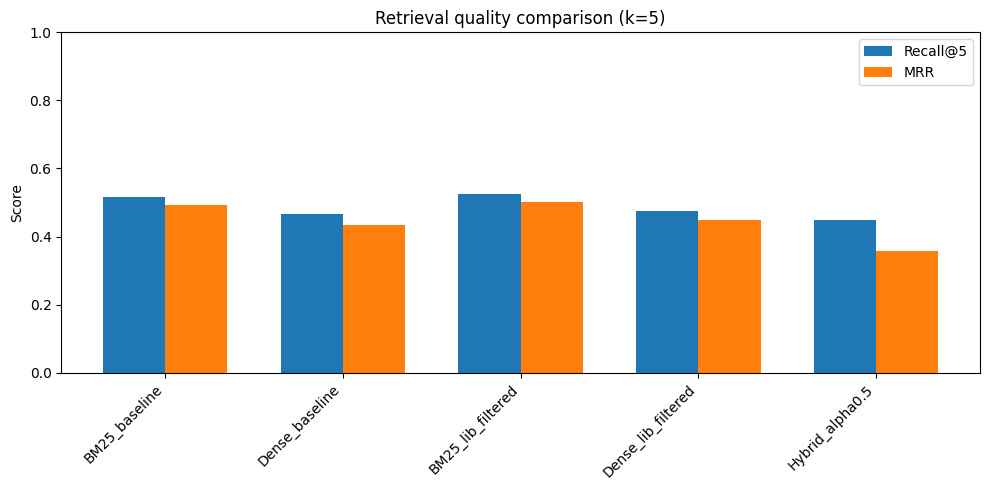

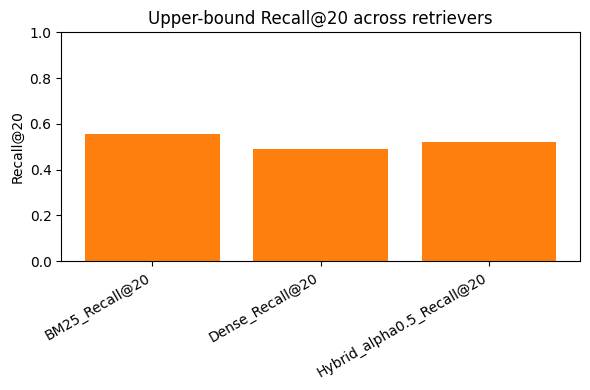

In [ ]:
# Visualization of retrieval quality

# Соберём данные для основных вариантов: baseline / lib-filtered / hybrid
methods = [
    "BM25_baseline",
    "Dense_baseline",
    "BM25_lib_filtered",
    "Dense_lib_filtered",
    "Hybrid_alpha0.5",
]

recalls = [RESULTS[m]["Recall@5"] for m in methods]
mrrs = [RESULTS[m]["MRR"] for m in methods]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, recalls, width, label="Recall@5")
plt.bar(x + width/2, mrrs, width, label="MRR")
plt.xticks(x, methods, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Retrieval quality comparison (k=5)")
plt.legend()
plt.tight_layout()
plt.show()

# Отдельно визуализируем Recall@20
methods_r20 = [
    "BM25_Recall@20",
    "Dense_Recall@20",
    "Hybrid_alpha0.5_Recall@20",
]

recalls20 = [RESULTS[m]["Recall@20"] for m in methods_r20]

plt.figure(figsize=(6, 4))
plt.bar(methods_r20, recalls20, color="tab:orange")
plt.ylim(0, 1)
plt.ylabel("Recall@20")
plt.title("Upper-bound Recall@20 across retrievers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import os
import re
import json
from itertools import islice

# ========= ПУТИ (v2) =========
# Берём исходный корпус и пишем более агрессивно очищенный
OLD_CORPUS_PATH = "rag_corpus/corpus.jsonl"
NEW_CORPUS_DIR = "rag_corpus_cleaned_v2"
NEW_CORPUS_PATH = os.path.join(NEW_CORPUS_DIR, "corpus.jsonl")

os.makedirs(NEW_CORPUS_DIR, exist_ok=True)

# ========= ПАТТЕРНЫ ДЛЯ ЖЁСТКОЙ ФИЛЬТРАЦИИ =========

LICENSE_RE = re.compile(r"^<!--Copyright .*? -->", re.IGNORECASE)

# строки / куски, которые считаем полностью мусором
LINE_SKIP_SUBSTRINGS = [
    "Copyright",
    "All rights reserved",
    "Licensed under the Apache License",
    "Note that this file is in Markdown",
    "colab.research.google.com",
    "Open In Colab",
    "Youtube id=",
    "<hfoptions",
    "<hfoption",
    "<Youtube",
    "<img ",
    "<div ",
    "</div>",
    "<Tip>",
    "</Tip>",
    "<Warning>",
    "</Warning>",
    "<details>",
    "</details>",
]

# имена файлов, которые целиком считаем нерелевантными
SOURCE_SKIP_SUBSTRINGS = [
    "community.md",
    "troubleshooting.md",
    "serialization.md",
    "optimizers.md",
    "perf_train_cpu_many.md",
    "cache_explanation.md",
]


def should_skip_source(source: str) -> bool:
    return any(pat in source for pat in SOURCE_SKIP_SUBSTRINGS)


def clean_markdown_strict(text: str) -> str:
    """Более строгая очистка markdown/HTML/MDX.

    - выбрасываем лицензии, MDX и html-блоки
    - удаляем картинки/ссылки/колабы/ютубы
    - убираем code-блоки ```...```
    - чистим инлайн-код, markdown-ссылки
    - выбрасываем чанки, если там остались html-теги или мусор
    """
    # построчная фильтрация явного мусора
    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        if LICENSE_RE.match(line):
            continue

        # выкидываем строки с явно служебным/MDX содержимым
        if any(sub in line for sub in LINE_SKIP_SUBSTRINGS):
            continue

        cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    # удаляем многострочные code-блоки ```...```
    text = re.sub(r"```[\s\S]*?```", "", text, flags=re.MULTILINE)

    # убираем HTML/MDX-теги целиком
    text = re.sub(r"<[^>]+>", " ", text)

    # инлайн‑код: убираем обратные кавычки, но оставляем содержимое
    text = text.replace("`", " ")

    # markdown‑ссылки [текст](url) → текст
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)

    # картинки ![alt](url) → убираем целиком
    text = re.sub(r"!\[[^\]]*\]\([^)]+\)", " ", text)

    # заголовки: убираем только #, текст оставляем
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.M)

    # схлопываем пробелы
    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    # финальная жёсткая фильтрация: выбрасываем, если остались теги/мусор
    BAD_FRAGMENT_SUBSTRINGS = ["<", ">", "colab.research.google.com", "Youtube id="]
    if any(bad in text for bad in BAD_FRAGMENT_SUBSTRINGS):
        return ""

    # очень короткие куски не берём
    if len(text) < 80:
        return ""

    return text


# ========= ПЕРЕЗАПИСЬ КОРПУСА (STRICT) =========

total_in = 0
total_out = 0

with open(OLD_CORPUS_PATH, "r", encoding="utf-8") as fin, \
     open(NEW_CORPUS_PATH, "w", encoding="utf-8") as fout:

    for line in fin:
        total_in += 1
        record = json.loads(line)

        # фильтрация по имени файла (source)
        src = record.get("source", "")
        if should_skip_source(src):
            continue

        original_text = record["text"]
        cleaned_text = clean_markdown_strict(original_text)

        if not cleaned_text:
            # полностью пустой или мусор после очистки — пропускаем
            continue

        record["text"] = cleaned_text
        fout.write(json.dumps(record, ensure_ascii=False) + "\n")
        total_out += 1

print(f"STRICT Готово. Прочитано строк: {total_in}, записано после очистки: {total_out}.")
print(f"Новый файл корпуса (strict): {NEW_CORPUS_PATH}\n")


# ========= ПРИМЕРЫ ДО/ПОСЛЕ (STRICT, из исходного файла) =========

N_EXAMPLES = 5
print(f"Первые {N_EXAMPLES} примеров ДО/ПОСЛЕ строгой очистки (из исходного корпуса):\n")

with open(OLD_CORPUS_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(islice(f, N_EXAMPLES), start=1):
        record = json.loads(line)
        original = record["text"]
        cleaned = clean_markdown_strict(original)

        print(f"=== Example {i} ===")
        print("SOURCE:", record.get("source"), "| LIB:", record.get("library"))
        print("\n--- ORIGINAL (truncated) ---")
        print(original[:500], "..." if len(original) > 500 else "")
        print("\n--- CLEANED STRICT (truncated) ---")
        print(cleaned[:500], "..." if len(cleaned) > 500 else "")
        print("\n" + "=" * 120 + "\n")

In [ ]:
import os
import re
import json
from itertools import islice

# ========= ПУТИ (v2) =========
# Берём исходный корпус и пишем более агрессивно очищенный
OLD_CORPUS_PATH = "rag_corpus/corpus.jsonl"
NEW_CORPUS_DIR = "rag_corpus_cleaned_v2"
NEW_CORPUS_PATH = os.path.join(NEW_CORPUS_DIR, "corpus.jsonl")

os.makedirs(NEW_CORPUS_DIR, exist_ok=True)

# ========= ПАТТЕРНЫ ДЛЯ ЖЁСТКОЙ ФИЛЬТРАЦИИ =========

LICENSE_RE = re.compile(r"^<!--Copyright .*? -->", re.IGNORECASE)

# строки / куски, которые считаем полностью мусором
LINE_SKIP_SUBSTRINGS = [
    "Copyright",
    "All rights reserved",
    "Licensed under the Apache License",
    "Note that this file is in Markdown",
    "colab.research.google.com",
    "Open In Colab",
    "Youtube id=",
    "<hfoptions",
    "<hfoption",
    "<Youtube",
    "<img ",
    "<div ",
    "</div>",
    "<Tip>",
    "</Tip>",
    "<Warning>",
    "</Warning>",
    "<details>",
    "</details>",
]

# имена файлов, которые целиком считаем нерелевантными
SOURCE_SKIP_SUBSTRINGS = [
    "community.md",
    "troubleshooting.md",
    "serialization.md",
    "optimizers.md",
    "perf_train_cpu_many.md",
    "cache_explanation.md",
]


def should_skip_source(source: str) -> bool:
    return any(pat in source for pat in SOURCE_SKIP_SUBSTRINGS)


def clean_markdown_strict(text: str) -> str:
    """Более строгая очистка markdown/HTML/MDX.

    - выбрасываем лицензии, MDX и html-блоки
    - удаляем картинки/ссылки/колабы/ютубы
    - убираем code-блоки ```...```
    - чистим инлайн-код, markdown-ссылки
    - выбрасываем чанки, если там остались html-теги или мусор
    """
    # построчная фильтрация явного мусора
    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        if LICENSE_RE.match(line):
            continue

        # выкидываем строки с явно служебным/MDX содержимым
        if any(sub in line for sub in LINE_SKIP_SUBSTRINGS):
            continue

        cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    # удаляем многострочные code-блоки ```...```
    text = re.sub(r"```[\s\S]*?```", "", text, flags=re.MULTILINE)

    # убираем HTML/MDX-теги целиком
    text = re.sub(r"<[^>]+>", " ", text)

    # инлайн‑код: убираем обратные кавычки, но оставляем содержимое
    text = text.replace("`", " ")

    # markdown‑ссылки [текст](url) → текст
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)

    # картинки ![alt](url) → убираем целиком
    text = re.sub(r"!\[[^\]]*\]\([^)]+\)", " ", text)

    # заголовки: убираем только #, текст оставляем
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.M)

    # схлопываем пробелы
    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    # финальная жёсткая фильтрация: выбрасываем, если остались теги/мусор
    BAD_FRAGMENT_SUBSTRINGS = ["<", ">", "colab.research.google.com", "Youtube id="]
    if any(bad in text for bad in BAD_FRAGMENT_SUBSTRINGS):
        return ""

    # очень короткие куски не берём
    if len(text) < 80:
        return ""

    return text


# ========= ПЕРЕЗАПИСЬ КОРПУСА (STRICT) =========

total_in = 0
total_out = 0

with open(OLD_CORPUS_PATH, "r", encoding="utf-8") as fin, \
     open(NEW_CORPUS_PATH, "w", encoding="utf-8") as fout:

    for line in fin:
        total_in += 1
        record = json.loads(line)

        # фильтрация по имени файла (source)
        src = record.get("source", "")
        if should_skip_source(src):
            continue

        original_text = record["text"]
        cleaned_text = clean_markdown_strict(original_text)

        if not cleaned_text:
            # полностью пустой или мусор после очистки — пропускаем
            continue

        record["text"] = cleaned_text
        fout.write(json.dumps(record, ensure_ascii=False) + "\n")
        total_out += 1

print(f"STRICT Готово. Прочитано строк: {total_in}, записано после очистки: {total_out}.")
print(f"Новый файл корпуса (strict): {NEW_CORPUS_PATH}\n")


# ========= ПРИМЕРЫ ДО/ПОСЛЕ (STRICT, из исходного файла) =========

N_EXAMPLES = 5
print(f"Первые {N_EXAMPLES} примеров ДО/ПОСЛЕ строгой очистки (из исходного корпуса):\n")

with open(OLD_CORPUS_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(islice(f, N_EXAMPLES), start=1):
        record = json.loads(line)
        original = record["text"]
        cleaned = clean_markdown_strict(original)

        print(f"=== Example {i} ===")
        print("SOURCE:", record.get("source"), "| LIB:", record.get("library"))
        print("\n--- ORIGINAL (truncated) ---")
        print(original[:500], "..." if len(original) > 500 else "")
        print("\n--- CLEANED STRICT (truncated) ---")
        print(cleaned[:500], "..." if len(cleaned) > 500 else "")
        print("\n" + "=" * 120 + "\n")

Готово. Прочитано строк: 1884, записано после очистки: 1007.
Новый файл корпуса: rag_corpus_cleaned/corpus.jsonl

Первые 5 примеров ДО/ПОСЛЕ (из старого файла):

=== Example 1 ===
SOURCE: chat_content_patterns.md | LIB: transformers

--- ORIGINAL (truncated) ---
<!--Copyright 2025 The HuggingFace Team. All rights reserved. Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for ...

--- CLEANED (truncated) ---
 


=== Example 2 ===
SOURCE: chat_content_patterns.md | LIB: transformers

--- ORIGINAL (truncated) ---
links or for local files. Mixed multiple The list accepts any combination of types. The model proc

In [4]:
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss


# ========= 1. ЗАГРУЗКА НОВОГО КОРПУСА =========

CORPUS_PATH = "corpus.jsonl"

documents = []
metadata = []

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        documents.append(record["text"])
        metadata.append({
            "source": record.get("source", ""),
            "library": record.get("library", "")
        })

print(f"Loaded {len(documents)} cleaned documents")


# ========= 2. BM25 =========

tokenized_docs = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_docs)

def bm25_retrieve(query: str, k: int = 5):
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_idx = np.argsort(scores)[::-1][:k]
    return [
        {
            "text": documents[i],
            "score": float(scores[i]),
            **metadata[i],
        }
        for i in top_idx
    ]


# ========= 3. DENSE (SBERT + FAISS) =========

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

print("Encoding documents...")
doc_embeddings = embedder.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)

dim = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(doc_embeddings)

print("FAISS index built")

def dense_retrieve(query: str, k: int = 5):
    query_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idx = index.search(query_emb, k)
    return [
        {
            "text": documents[i],
            "score": float(scores[0][j]),
            **metadata[i],
        }
        for j, i in enumerate(idx[0])
    ]


# ========= 4. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ОЦЕНКИ =========

import random
import re

def generate_query_from_chunk(text: str) -> str:
    sentences = re.split(r"[.!?]", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    return " ".join(sentences[:2])

def evaluate_retriever(
    retrieve_fn,
    documents,
    metadata,
    k: int = 5,
    n_samples: int = 200,
    seed: int = 42,
):
    random.seed(seed)
    n_samples = min(n_samples, len(documents))
    indices = random.sample(range(len(documents)), n_samples)

    hits = 0
    rr_sum = 0.0

    for idx in tqdm(indices, desc="Evaluating"):
        query = generate_query_from_chunk(documents[idx])
        true_source = metadata[idx]["source"]

        results = retrieve_fn(query, k=k)

        for rank, res in enumerate(results, start=1):
            if res["source"] == true_source:
                hits += 1
                rr_sum += 1.0 / rank
                break

    recall = hits / n_samples
    mrr = rr_sum / n_samples

    return {
        f"Recall@{k}": round(recall, 4),
        "MRR": round(mrr, 4),
        "Samples": n_samples,
    }

def evaluate_recall_at_k(
    retrieve_fn,
    documents,
    metadata,
    k: int,
    n_samples: int = 200,
    seed: int = 42,
):
    random.seed(seed)
    n_samples = min(n_samples, len(documents))
    indices = random.sample(range(len(documents)), n_samples)

    hits = 0

    for idx in tqdm(indices, desc=f"Evaluating Recall@{k}"):
        query = generate_query_from_chunk(documents[idx])
        true_source = metadata[idx]["source"]

        results = retrieve_fn(query, k=k)
        if any(res["source"] == true_source for res in results):
            hits += 1

    recall = hits / n_samples
    return {f"Recall@{k}": round(recall, 4), "Samples": n_samples}


# ========= 5. ВАРИАНТЫ RETRIEVAL (FILTER + HYBRID) =========

def bm25_retrieve_filtered(query: str, k: int = 5, library: str | None = None):
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)

    if library is not None:
        mask = np.array([m["library"] == library for m in metadata])
        scores_filtered = np.where(mask, scores, -1e9)
    else:
        scores_filtered = scores

    top_idx = np.argsort(scores_filtered)[::-1][:k]
    return [
        {
            "text": documents[i],
            "score": float(scores_filtered[i]),
            **metadata[i],
        }
        for i in top_idx
    ]

def dense_retrieve_filtered(query: str, k: int = 5, library: str | None = None):
    query_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idx = index.search(query_emb, len(documents))
    scores = scores[0]
    idx = idx[0]

    if library is not None:
        filtered = [
            (i, s)
            for i, s in zip(idx, scores)
            if metadata[i]["library"] == library
        ]
        if not filtered:
            return dense_retrieve(query, k=k)
        idx, scores = zip(*filtered)
        idx = np.array(idx)
        scores = np.array(scores)

    order = np.argsort(scores)[::-1][:k]
    return [
        {
            "text": documents[i],
            "score": float(scores[j]),
            **metadata[i],
        }
        for j, i in enumerate(idx[order])
    ]

def evaluate_retriever_with_library_filter(
    retrieve_fn,
    documents,
    metadata,
    k: int = 5,
    n_samples: int = 200,
    seed: int = 42,
):
    random.seed(seed)
    n_samples = min(n_samples, len(documents))
    indices = random.sample(range(len(documents)), n_samples)

    hits = 0
    rr_sum = 0.0

    for idx in tqdm(indices, desc="Evaluating (lib-filter)"):
        query = generate_query_from_chunk(documents[idx])
        true_source = metadata[idx]["source"]
        true_library = metadata[idx]["library"]

        results = retrieve_fn(query, k=k, library=true_library)

        for rank, res in enumerate(results, start=1):
            if res["source"] == true_source:
                hits += 1
                rr_sum += 1.0 / rank
                break

    recall = hits / n_samples
    mrr = rr_sum / n_samples

    return {
        f"Recall@{k}": round(recall, 4),
        "MRR": round(mrr, 4),
        "Samples": n_samples,
    }

def hybrid_retrieve(query: str, k: int = 5, alpha: float = 0.5):
    # BM25
    tokens = query.lower().split()
    bm25_scores = bm25.get_scores(tokens)

    # Dense
    query_emb = embedder.encode([query], normalize_embeddings=True)
    dense_scores, _ = index.search(query_emb, len(documents))
    dense_scores = dense_scores[0]

    def _normalize(x):
        x = np.array(x, dtype=float)
        return (x - x.min()) / (x.ptp() + 1e-8)

    bm25_norm = _normalize(bm25_scores)
    dense_norm = _normalize(dense_scores)

    hybrid_scores = alpha * bm25_norm + (1.0 - alpha) * dense_norm
    top_idx = np.argsort(hybrid_scores)[::-1][:k]

    return [
        {
            "text": documents[i],
            "score": float(hybrid_scores[i]),
            **metadata[i],
        }
        for i in top_idx
    ]


# ========= 6. ЗАПУСК ЭКСПЕРИМЕНТОВ =========

RESULTS = {}

print("\nRunning BM25 baseline...")
RESULTS["BM25_baseline"] = evaluate_retriever(
    bm25_retrieve,
    documents,
    metadata,
    k=5,
    n_samples=200,
)

print("\nRunning Dense baseline...")
RESULTS["Dense_baseline"] = evaluate_retriever(
    dense_retrieve,
    documents,
    metadata,
    k=5,
    n_samples=200,
)

print("\nRunning BM25 (library-filtered)...")
RESULTS["BM25_lib_filtered"] = evaluate_retriever_with_library_filter(
    bm25_retrieve_filtered,
    documents,
    metadata,
    k=5,
    n_samples=200,
)

print("\nRunning Dense (library-filtered)...")
RESULTS["Dense_lib_filtered"] = evaluate_retriever_with_library_filter(
    dense_retrieve_filtered,
    documents,
    metadata,
    k=5,
    n_samples=200,
)

print("\nRunning Hybrid (alpha=0.5)...")
RESULTS["Hybrid_alpha0.5"] = evaluate_retriever(
    lambda q, k: hybrid_retrieve(q, k=k, alpha=0.5),
    documents,
    metadata,
    k=5,
    n_samples=200,
)

print("\nRunning Recall@20 (BM25)...")
RESULTS["BM25_Recall@20"] = evaluate_recall_at_k(
    bm25_retrieve,
    documents,
    metadata,
    k=20,
    n_samples=200,
)

print("\nRunning Recall@20 (Dense)...")
RESULTS["Dense_Recall@20"] = evaluate_recall_at_k(
    dense_retrieve,
    documents,
    metadata,
    k=20,
    n_samples=200,
)

print("\nRunning Recall@20 (Hybrid alpha=0.5)...")
RESULTS["Hybrid_alpha0.5_Recall@20"] = evaluate_recall_at_k(
    lambda q, k: hybrid_retrieve(q, k=k, alpha=0.5),
    documents,
    metadata,
    k=20,
    n_samples=200,
)

print("\n=== ALL RESULTS (raw) ===")
for name, metrics in RESULTS.items():
    print(name, ":", metrics)


# ========= 7. ВИЗУАЛИЗАЦИЯ =========

methods = [
    "BM25_baseline",
    "Dense_baseline",
    "BM25_lib_filtered",
    "Dense_lib_filtered",
    "Hybrid_alpha0.5",
]

recalls = [RESULTS[m]["Recall@5"] for m in methods]
mrrs = [RESULTS[m]["MRR"] for m in methods]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, recalls, width, label="Recall@5")
plt.bar(x + width/2, mrrs, width, label="MRR")
plt.xticks(x, methods, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Retrieval quality comparison (k=5) on cleaned_v2 corpus")
plt.legend()
plt.tight_layout()
plt.show()

methods_r20 = [
    "BM25_Recall@20",
    "Dense_Recall@20",
    "Hybrid_alpha0.5_Recall@20",
]

recalls20 = [RESULTS[m]["Recall@20"] for m in methods_r20]

plt.figure(figsize=(6, 4))
plt.bar(methods_r20, recalls20, color="tab:orange")
plt.ylim(0, 1)
plt.ylabel("Recall@20")
plt.title("Upper-bound Recall@20 across retrievers (cleaned_v2)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'faiss'

In [15]:
# =============================================================================
# RAG SYSTEM WITH LLAMAINDEX (ПОЛНОСТЬЮ РАБОЧАЯ ВЕРСИЯ)
# =============================================================================

import json
import torch
import gc
import time
import os
import warnings

warnings.filterwarnings("ignore")

# =============================================================================
# 1. НАСТРОЙКА LLM С КВАНТОВАНИЕМ (ПРЕДВАРИТЕЛЬНАЯ ЗАГРУЗКА)
# =============================================================================

print("🔧 Настройка LLM (Mistral-7B с 4-битным квантованием)...")

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from llama_index.llms.huggingface import HuggingFaceLLM

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

# ✅ Шаг 1: Сначала загружаем модель самостоятельно с квантованием
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("  - Загрузка модели...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=quantization_config,
    trust_remote_code=True
)

print("  - Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ✅ Шаг 2: Передаём готовую модель в LlamaIndex БЕЗ max_new_tokens в generate_kwargs
llm = HuggingFaceLLM(
    model=model,
    tokenizer=tokenizer,
    context_window=4096,
    max_new_tokens=512,  # 👈 Только здесь, НЕ в generate_kwargs
    generate_kwargs={
        "temperature": 0.3,
        "do_sample": True,
        "top_p": 0.9,
        "top_k": 50,
        "repetition_penalty": 1.1,
        # ❌ НЕ добавляйте max_new_tokens сюда!
    },
)

model.eval()  # Режим оценки

print("✅ LLM загружена")

# =============================================================================
# 2. НАСТРОЙКА EMBEDDING МОДЕЛИ
# =============================================================================

print("\n🔧 Настройка embedding модели...")

from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5",
    device="cuda" if torch.cuda.is_available() else "cpu",
    normalize=True,
)

from llama_index.core import Settings

Settings.llm = llm
Settings.embed_model = embed_model
Settings.chunk_size = 512
Settings.chunk_overlap = 50

print("✅ Embedding модель загружена")

# =============================================================================
# 3. ЗАГРУЗКА ДОКУМЕНТОВ
# =============================================================================

CORPUS_PATH = "corpus.jsonl"

print(f"\n📚 Загрузка документов из {CORPUS_PATH}...")

from llama_index.core import Document

documents = []

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        doc = Document(
            text=record["text"],
            metadata={
                "source": record.get("source", ""),
                "library": record.get("library", ""),
            },
        )
        documents.append(doc)

print(f"✅ Загружено {len(documents)} документов")

# =============================================================================
# 4. СОЗДАНИЕ ИНДЕКСА
# =============================================================================

PERSIST_DIR = "./storage"
INDEX_EXISTS = False

if os.path.exists(PERSIST_DIR):
    print(f"\n📂 Найден существующий индекс в {PERSIST_DIR}")
    try:
        from llama_index.core import StorageContext, load_index_from_storage
        storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
        index = load_index_from_storage(storage_context)
        INDEX_EXISTS = True
        print("✅ Индекс загружен")
    except Exception as e:
        print(f"⚠️ Ошибка загрузки индекса: {e}")
        INDEX_EXISTS = False

if not INDEX_EXISTS:
    print("\n🔨 Создание нового индекса...")

    from llama_index.core.node_parser import SentenceSplitter
    from llama_index.core import VectorStoreIndex

    node_parser = SentenceSplitter(chunk_size=512, chunk_overlap=50)

    index = VectorStoreIndex.from_documents(
        documents,
        node_parser=node_parser,
        show_progress=True,
    )

    print(f"\n💾 Сохранение индекса в {PERSIST_DIR}...")
    index.storage_context.persist(persist_dir=PERSIST_DIR)
    print("✅ Индекс создан и сохранён")

# =============================================================================
# 5. НАСТРОЙКА RETRIEVER
# =============================================================================

print("\n🔧 Настройка retriever...")

from llama_index.core.retrievers import VectorIndexRetriever

RETRIEVER_MODE = "vector"  # Для начала без гибридного поиска
TOP_K = 5

vector_retriever = VectorIndexRetriever(index=index, similarity_top_k=TOP_K)
retriever = vector_retriever

print("✅ Векторный retriever настроен")

# =============================================================================
# 6. НАСТРОЙКА QUERY ENGINE
# =============================================================================

print("\n🔧 Настройка query engine...")

from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SimilarityPostprocessor

query_engine = RetrieverQueryEngine(
    retriever=retriever,
    node_postprocessors=[SimilarityPostprocessor(similarity_cutoff=0.0)],
)

print("✅ Query engine готов")

# =============================================================================
# 7. КАСТОМНЫЙ ПРОМПТ
# =============================================================================

from llama_index.core.prompts import PromptTemplate

QA_PROMPT = PromptTemplate("""
<|system|>
You are a helpful assistant that answers questions based ONLY on the provided documentation context from Hugging Face libraries.

IMPORTANT RULES:
- If the answer is not contained in the context, say "I don't know based on the provided context."
- Do not make up information or use your internal knowledge.
- Answer concisely and accurately.
- When possible, mention the source file name.
</|system|>

<|user|>
Context information is below.
---------------------
{context_str}
---------------------
Given the context information and not prior knowledge, answer the query.

Query: {query_str}
Answer:
</|user|>

<|assistant|>
""")

query_engine.update_prompts({"response_synthesizer:text_qa_template": QA_PROMPT})

print("✅ Промпт настроен")

# =============================================================================
# 8. ТЕСТОВЫЕ ЗАПРОСЫ
# =============================================================================

TEST_QUERIES = [
    "What is the Trainer class used for in transformers?",
    "How can I fine-tune a pretrained transformer model?",
    "How do I load a dataset from the Hugging Face Hub?",
]

# =============================================================================
# 9. ЗАПУСК RAG
# =============================================================================

print("\n" + "=" * 100)
print("🚀 ЗАПУСК RAG SYSTEM")
print("=" * 100 + "\n")

results_log = []

for i, query in enumerate(TEST_QUERIES, 1):
    print(f"\n{'=' * 100}")
    print(f"📌 [{i}/{len(TEST_QUERIES)}] QUERY:\n{query}\n")
    print("=" * 100)

    start_time = time.time()

    try:
        print(f"🔍 Поиск и генерация ({RETRIEVER_MODE})...")

        response = query_engine.query(query)

        print(f"\n📚 RETRIEVED CONTEXT (top {len(response.source_nodes)} chunks):\n")
        for j, node in enumerate(response.source_nodes, 1):
            source = node.metadata.get("source", "unknown")
            library = node.metadata.get("library", "unknown")
            score = node.score if hasattr(node, 'score') else "N/A"
            text_preview = node.text[:200]
            print(f"[{j}] ({library} | {source}) | Score: {score}")
            print(f"    {text_preview}...")
            print()

        print("\n🤖 MODEL ANSWER:\n")
        print(f"{response.response}\n")

        results_log.append({
            "query": query,
            "answer": response.response,
            "status": "success",
            "chunks_found": len(response.source_nodes),
            "retriever": RETRIEVER_MODE,
        })

    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        results_log.append({"query": query, "answer": str(e), "status": "error"})

    finally:
        torch.cuda.empty_cache()
        gc.collect()

        elapsed = time.time() - start_time
        print(f"⏱️ Время выполнения: {elapsed:.2f} сек")
        print(f"📊 Память GPU: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
        print("-" * 100)

# =============================================================================
# 10. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# =============================================================================

print("\n✅ RAG ЗАВЕРШЁН\n")

with open("rag_results_llamaindex.json", "w", encoding="utf-8") as f:
    json.dump(results_log, f, ensure_ascii=False, indent=2)

print(f"📁 Результаты сохранены в rag_results_llamaindex.json")
print(f"📊 Успешных: {sum(1 for r in results_log if r['status'] == 'success')}")
print(f"📊 Ошибок: {sum(1 for r in results_log if r['status'] == 'error')}")

🔧 Настройка LLM (Mistral-7B с 4-битным квантованием)...
  - Загрузка модели...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  - Загрузка токенизатора...
✅ LLM загружена

🔧 Настройка embedding модели...
✅ Embedding модель загружена

📚 Загрузка документов из corpus.jsonl...
✅ Загружено 426 документов

📂 Найден существующий индекс в ./storage


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


✅ Индекс загружен

🔧 Настройка retriever...
✅ Векторный retriever настроен

🔧 Настройка query engine...
✅ Query engine готов
✅ Промпт настроен

🚀 ЗАПУСК RAG SYSTEM


📌 [1/3] QUERY:
What is the Trainer class used for in transformers?

🔍 Поиск и генерация (vector)...

📚 RETRIEVED CONTEXT (top 5 chunks):

[1] (transformers | model_doc/pvt_v2.md) | Score: 0.722156761027571
    [] adds a simple classifier head on top to perform Image Classification. [] can be used with the [] system in larger architectures like Deformable DETR. - ImageNet pretrained weights for all model siz...

[2] (transformers | internal/rope_utils.md) | Score: 0.7192603532177333
    such as Gemma-3 use different layer types with different attention mechanisms, i.e. "full attention" in some blocks and "sliding-window attention" in others. Transformers supports specifying distinct ...

[3] (transformers | tasks/image_feature_extraction.md) | Score: 0.7013223993673677
    avoid passing any value for the parameter, as it is

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


⏱️ Время выполнения: 9.11 сек
📊 Память GPU: 4.36 GB
----------------------------------------------------------------------------------------------------

📌 [2/3] QUERY:
How can I fine-tune a pretrained transformer model?

🔍 Поиск и генерация (vector)...

📚 RETRIEVED CONTEXT (top 5 chunks):

[1] (transformers | model_doc/udop.md) | Score: 0.7706589920458617
    - One can also fine-tune [], which is the encoder-only part of UDOP, which can be seen as a LayoutLMv3-like Transformer encoder. For discriminative tasks, one can just add a linear classifier on top o...

[2] (transformers | model_doc/mixtral.md) | Score: 0.767766025993112
    direct preference optimization with Mistral-7B. This includes scripts for full fine-tuning, QLoRa on a single accelerator as well as multi-accelerator fine-tuning. - Causal language modeling task guid...

[3] (transformers | add_new_model.md) | Score: 0.7641191937582172
    initialized weights and save those weights to compare against the Transformers imple

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


⏱️ Время выполнения: 29.40 сек
📊 Память GPU: 4.36 GB
----------------------------------------------------------------------------------------------------

📌 [3/3] QUERY:
How do I load a dataset from the Hugging Face Hub?

🔍 Поиск и генерация (vector)...

📚 RETRIEVED CONTEXT (top 5 chunks):

[1] (transformers | contributing.md) | Score: 0.8163137644750723
    Instead, use a Hub repository such as [](https://huggingface.co/hf-internal-testing) to host these files and reference them by URL. We recommend placing documentation related images in the following r...

[2] (transformers | tasks/object_detection.md) | Score: 0.7636681440860635
    157600 0.386200 0.250100 0.395100 30 0.993700 1.346446 0.277400 0.554700 0.252700 0.147900 0.240800 0.523600 0.278800 0.420400 0.443300 0.256100 0.424200 0.705500 0.530100 0.646800 0.275600 0.440500 0...

[3] (transformers | model_doc/lilt.md) | Score: 0.7493913238937836
    the Language-Independent Layout Transformer with a new RoBERTa checkpoint from 

In [6]:
pip install llama_index.embeddings.huggingface